#  <center> Taller  de Aprendizaje Automático </center>
##  <center> Taller 6: Fashion MNIST  </center>

En esta actividad se diseñará y entrenará una arquitectura para clasificar las imágenes del dataset *Fashion MNIST*. 

## Objetivos

 - Adquirir experiencia práctica en la implementación de redes neuronales con la biblioteca *keras*
 - Evaluar la influencia que tienen en el entrenamiento de una *red profunda* la inclusión de técnicas como *Batch Normalization* o *Dropout* en la arquitectura de la red.
 - Evaluar el impacto de la *inicialización* de los pesos en el entrenamiento de una *red profunda*.
 - Diseñar, entrenar y evaluar arquitecturas para clasificar imágenes.  


<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/TAA-fing/TAA-2026/blob/main/talleres/taller6_Fashion-MNIST.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Ejecutar en Google Colab</a>
  </td>
</table>

In [1]:
import ctypes
import site
from pathlib import Path

# En WSL/VS Code, TensorFlow 2.21 puede no encontrar cuSOLVER automáticamente.
cusolver_path = (
    Path(site.getusersitepackages())
    / "nvidia"
    / "cusolver"
    / "lib"
    / "libcusolver.so.11"
)
if cusolver_path.exists():
    ctypes.CDLL(str(cusolver_path), mode=ctypes.RTLD_GLOBAL)

from comet_ml import Experiment
import tensorflow as tf
from tensorflow import keras
import numpy as np
from matplotlib import pyplot as plt
import os
import pandas as pd

/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
I0000 00:00:1780855289.460968   10668 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Los paquetes faltantes se pueden instalar desde el notebook haciendo:     
*!pip install paquete_faltante*

### Parte 1 - Levantar los datos

Se trabajará con el conjunto de datos *Fashion MNIST* disponible en [*Keras*](https://keras.io/api/datasets/fashion_mnist/). Levantar los datos y separar, de los datos disponibles para entrenamiento, un subconjunto de 10000 muestras para validación. 

In [2]:
fashion_mnist = keras.datasets.fashion_mnist

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

X_valid = X_train_full[:10000].astype("float32") / 255.0
X_train = X_train_full[10000:].astype("float32") / 255.0

y_valid = y_train_full[:10000]
y_train = y_train_full[10000:]

X_test = X_test.astype("float32") / 255.0

### Parte 2  - Exploración de datos

Como es habitual, una buena práctica es explorar los datos para familiarizarse con el problema. 

Conteste a las siguientes preguntas:        
    - ¿Cuántas imágenes hay disponibles? ¿De qué tamaño son?       
    - ¿Cuál es el tipo de dato? ¿Es adecuado?         
Muestre las primeras $n$ imágenes del dataset con $n=25$ o un $n$ que le permita ver ejemplos de todas las clases.

Entrenamiento: X=(50000, 28, 28), y=(50000,)
Validación:    X=(10000, 28, 28), y=(10000,)
Test:          X=(10000, 28, 28), y=(10000,)

Tipo de las imágenes: float32
Tipo de las etiquetas: uint8
Rango de los píxeles: [0.0, 1.0]
Clases disponibles: [0 1 2 3 4 5 6 7 8 9]


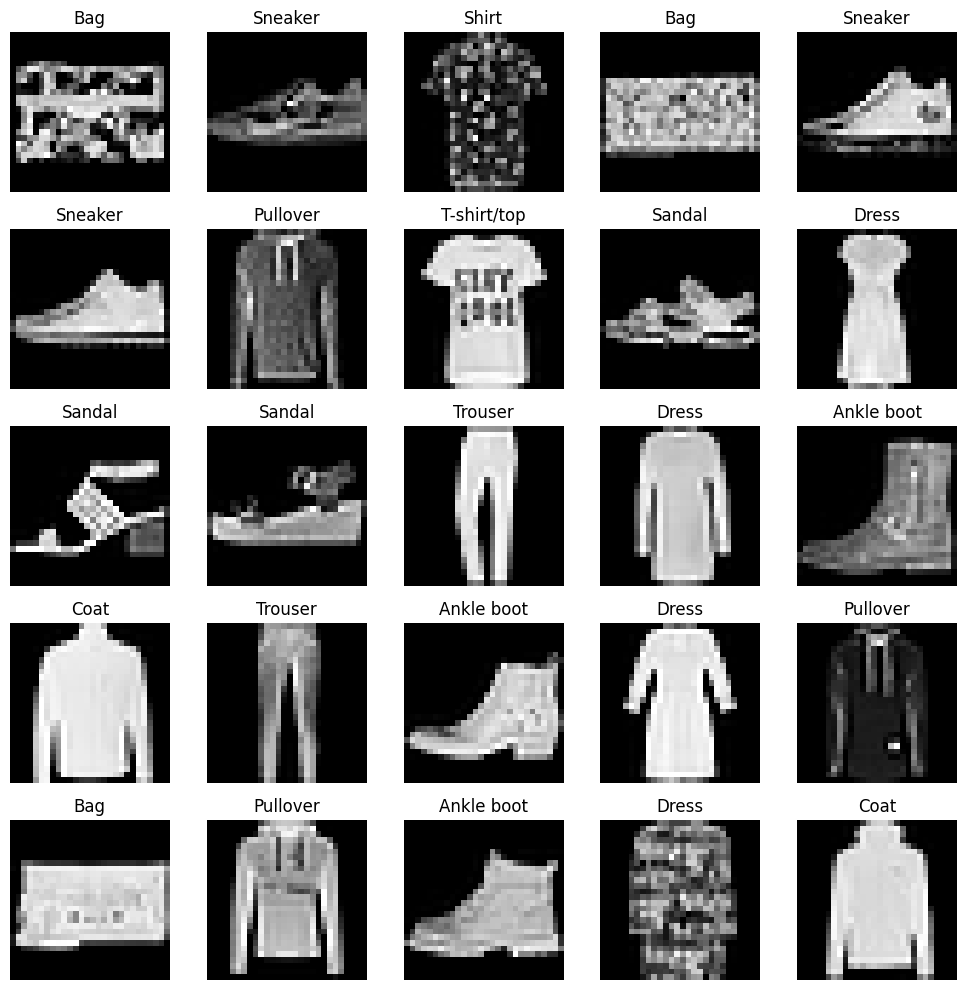

In [3]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

print(f"Entrenamiento: X={X_train.shape}, y={y_train.shape}")
print(f"Validación:    X={X_valid.shape}, y={y_valid.shape}")
print(f"Test:          X={X_test.shape}, y={y_test.shape}")
print()
print(f"Tipo de las imágenes: {X_train.dtype}")
print(f"Tipo de las etiquetas: {y_train.dtype}")
print(f"Rango de los píxeles: [{X_train.min()}, {X_train.max()}]")
print(f"Clases disponibles: {np.unique(y_train)}")

fig, axes = plt.subplots(5, 5, figsize=(10, 10))

for index, ax in enumerate(axes.flat):
    ax.imshow(X_train[index], cmap="gray")
    ax.set_title(class_names[y_train[index]])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Exploracion de balance de clases y ejemplos

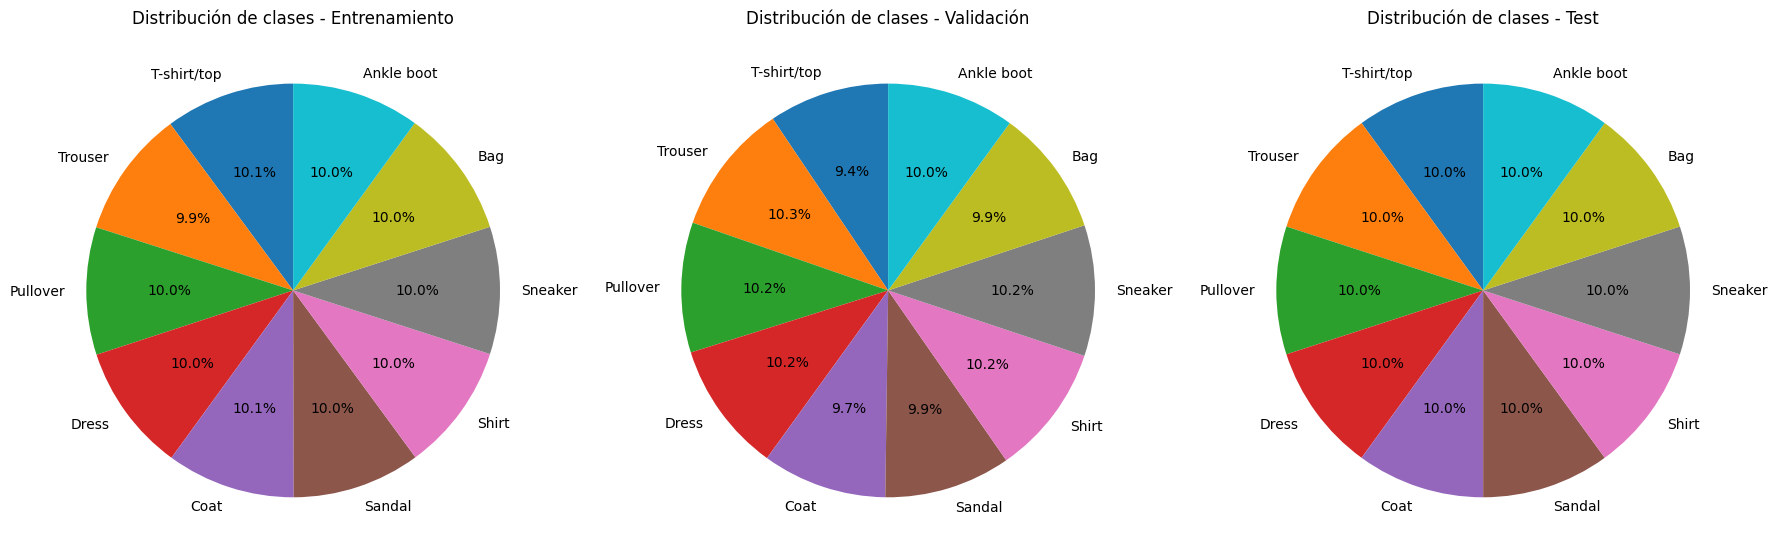

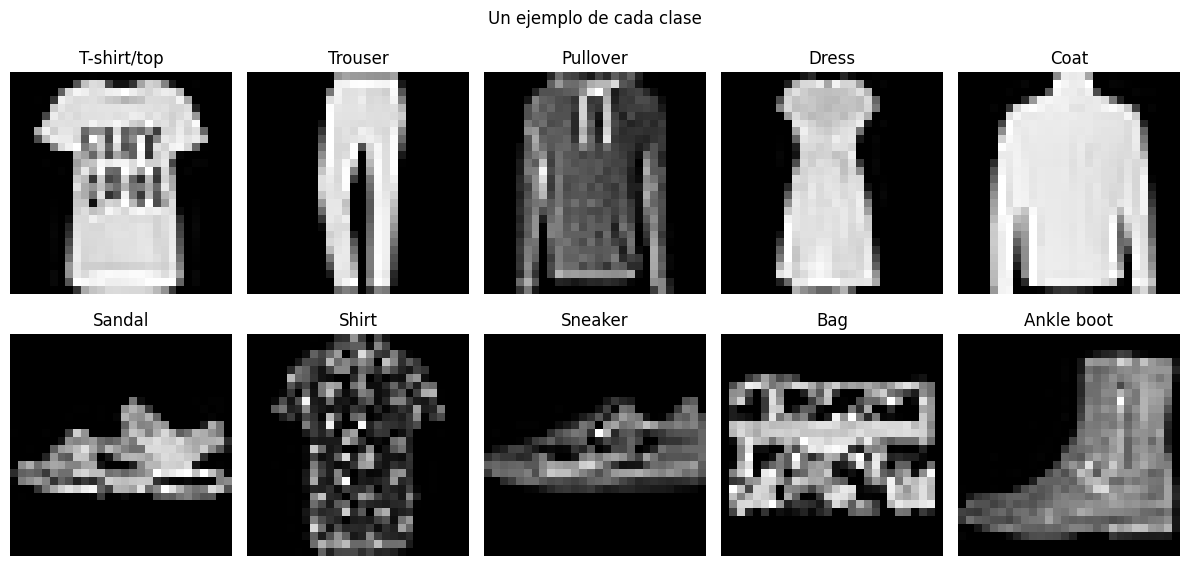

In [4]:
datasets = {
    "Entrenamiento": y_train,
    "Validación": y_valid,
    "Test": y_test,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (dataset_name, labels) in zip(axes, datasets.items()):
    class_counts = np.bincount(labels, minlength=len(class_names))
    ax.pie(
        class_counts,
        labels=class_names,
        autopct="%1.1f%%",
        startangle=90,
    )
    ax.set_title(f"Distribución de clases - {dataset_name}")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for class_index, ax in enumerate(axes.flat):
    example_index = np.flatnonzero(y_train == class_index)[0]
    ax.imshow(X_train[example_index], cmap="gray")
    ax.set_title(class_names[class_index])
    ax.axis("off")

plt.suptitle("Un ejemplo de cada clase")
plt.tight_layout()
plt.show()

#### Respuestas

- Luego de separar el conjunto original de entrenamiento, hay **50.000 imágenes de entrenamiento**, **10.000 de validación** y **10.000 de test**.
- Cada imagen tiene un tamaño de **28 × 28 píxeles** y está representada en escala de grises.
- Las imágenes tienen tipo `float32`, adecuado para trabajar con TensorFlow, y sus píxeles fueron normalizados al intervalo `[0, 1]`.
- Las etiquetas son números enteros entre `0` y `9`. Cada número representa una de las diez clases de prendas de Fashion MNIST.

### Parte 3 - Un primer modelo

Construya una red neuronal totalmente conectada de 20 capas y 100 neuronas por capa. Para ello se sugiere completar la implementación de la función `fully_connected_model`. Utilice *relu* como función de activación y *sgd* como optimizador.  Indique cuántos parámetros tiene la red.

In [15]:
def fully_connected_model(input_shape, n_hiddens, n_neurons, activation='relu', 
                        optimizer='sgd', learning_rate = 1e-3,
                        kernel_initializer="glorot_uniform",
                        use_batch_norm=False):
    
    '''
    Entrada:
        input_shape: [M,N]
        n_hiddens: número de capas ocultas
        n_neurons: número de neuronas en cada capa oculta
        activation: función de activación de las neuronas. Por defecto 'relu'.
        optimizer: método de optimización. Por defecto 'sgd'.
        learning_rate: tasa de aprendizaje del optimizador. Por defecto 1e-3.
        kernel_initializer: inicialización de pesos para las capas ocultas.
        use_batch_norm: si es True agrega Batch Normalization antes de la activación.
    Salida:
        model: modelo generado
    '''

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=input_shape))
    model.add(keras.layers.Flatten())

    for _ in range(n_hiddens):
        if use_batch_norm:
            model.add(
                keras.layers.Dense(
                    n_neurons,
                    kernel_initializer=kernel_initializer,
                    use_bias=False,
                )
            )
            model.add(keras.layers.BatchNormalization())
            model.add(keras.layers.Activation(activation))
        else:
            model.add(
                keras.layers.Dense(
                    n_neurons,
                    activation=activation,
                    kernel_initializer=kernel_initializer,
                )
            )

    model.add(keras.layers.Dense(10, activation="softmax"))

    optimizer_instance = keras.optimizers.get(optimizer)
    optimizer_instance.learning_rate = learning_rate

    model.compile(
        optimizer=optimizer_instance,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


model = fully_connected_model(
    input_shape=X_train.shape[1:],
    n_hiddens=20,
    n_neurons=100,
    activation="relu",
    optimizer="sgd",
    learning_rate=1e-3,
)

model.summary()


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_14 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_294 (Dense)               │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_295 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_296 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_297 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_298 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_299 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_300 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_301 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_302 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_303 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_304 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_305 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_306 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_307 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_308 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_309 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_310 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_311 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_312 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_313 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_314 (Dense)               │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,410 (1.04 MB)

 Trainable params: 271,410 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

### Adaptación de WSL para usar GPU local

In [6]:
gpus = tf.config.list_physical_devices("GPU")

if not gpus:
    print("TensorFlow no detectó una GPU.")
else:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError:
            # El runtime puede haberse inicializado al construir el modelo anterior.
            pass

    print("GPU detectada:", gpus[0].name)

    with tf.device("/GPU:0"):
        gpu_test = tf.matmul(
            tf.random.normal((1000, 1000)),
            tf.random.normal((1000, 1000)),
        )

    print("Operación ejecutada en:", gpu_test.device)

GPU detectada: /physical_device:GPU:0
Operación ejecutada en: /job:localhost/replica:0/task:0/device:GPU:0


### Parte 4 -  Un primer entrenamiento

Entrene el modelo generado en la parte anterior durante 10 épocas para los siguientes valores de *learning rate*: [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]. Muestre los desempeños en los conjuntos de entrenamiento y validación. 

In [7]:
learning_rates = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
part4_histories = {}
part4_results = []

Entrenando modelo con learning_rate=0.0001


I0000 00:00:1780855298.410076   10780 service.cc:153] XLA service 0x78ba98035da0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780855298.410114   10780 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780855298.430666   10780 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780855298.773749   10780 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1780855298.782508   10780 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2202__.31
I0000 00:00:1780855299.452203   10780 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

Entrenando modelo con learning_rate=0.0005


I0000 00:00:1780855333.507070   10781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23448__.31
I0000 00:00:1780855336.808694   10780 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23448__.31


Entrenando modelo con learning_rate=0.001


...

I0000 00:00:1780855389.444286   10780 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_65940__.31
I0000 00:00:1780855392.676417   10781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_65940__.31


Entrenando modelo con learning_rate=0.01


I0000 00:00:1780855423.304450   10780 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_87186__.31
I0000 00:00:1780855426.753685   10779 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_87186__.31


,learning_rate,train_loss,train_accuracy,valid_loss,valid_accuracy
4,0.0100,0.715160,0.72170,0.679176,0.7439
3,0.0050,1.462562,0.46026,1.203407,0.5649
0,0.0001,2.302424,0.18468,2.302415,0.1997
1,0.0005,2.301950,0.12236,2.301945,0.1075
2,0.0010,2.301061,0.10254,2.300920,0.0942


Mejor learning rate según accuracy de validación: 0.01


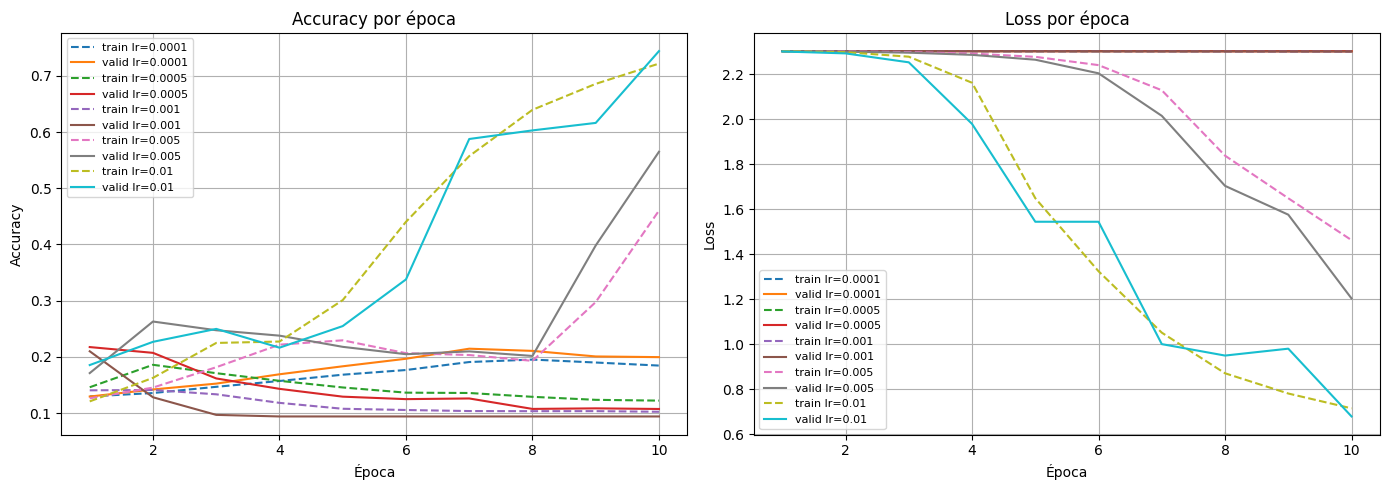

In [8]:
for learning_rate in learning_rates:
    keras.utils.set_random_seed(42)

    candidate_model = fully_connected_model(
        input_shape=X_train.shape[1:],
        n_hiddens=20,
        n_neurons=100,
        activation="relu",
        optimizer="sgd",
        learning_rate=learning_rate,
    )

    print(f"Entrenando modelo con learning_rate={learning_rate:g}")
    history = candidate_model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=128,
        validation_data=(X_valid, y_valid),
        verbose=0,
    )

    part4_histories[learning_rate] = history
    part4_results.append(
        {
            "learning_rate": learning_rate,
            "train_loss": history.history["loss"][-1],
            "train_accuracy": history.history["accuracy"][-1],
            "valid_loss": history.history["val_loss"][-1],
            "valid_accuracy": history.history["val_accuracy"][-1],
        }
    )

part4_results_df = pd.DataFrame(part4_results).sort_values(
    "valid_accuracy",
    ascending=False,
)
best_learning_rate = part4_results_df.iloc[0]["learning_rate"]

display(part4_results_df)
print(f"Mejor learning rate según accuracy de validación: {best_learning_rate:g}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for learning_rate, history in part4_histories.items():
    epochs = range(1, len(history.history["accuracy"]) + 1)
    label = f"lr={learning_rate:g}"

    axes[0].plot(epochs, history.history["accuracy"], linestyle="--", label=f"train {label}")
    axes[0].plot(epochs, history.history["val_accuracy"], label=f"valid {label}")

    axes[1].plot(epochs, history.history["loss"], linestyle="--", label=f"train {label}")
    axes[1].plot(epochs, history.history["val_loss"], label=f"valid {label}")

axes[0].set_title("Accuracy por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")

axes[1].set_title("Loss por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")

for ax in axes:
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Interpretacion visual

Podemos observar que para diferentes valores de *learning rate*, tenemos diferentes resultados:

- Con `learning_rate=1e-4`, `5e-4` y `1e-3`, la red casi no aprende durante las 10 épocas. La *loss* queda cerca de `2.30`, que es aproximadamente `log(10)`, el valor esperado cuando el modelo predice casi de forma uniforme entre las 10 clases.
- Con `learning_rate=5e-3`, el modelo empieza a aprender, pero todavía queda lejos del mejor desempeño observado.
- Con `learning_rate=1e-2`, el entrenamiento mejora claramente, alcanza la mayor exactitud de validación, aproximadamente `0.75`, y la menor *loss* de validación.

Visualmente, las curvas de *accuracy* deberían mostrar que los modelos con *learning rate* bajo permanecen casi planos, mientras que el modelo con `1e-2` sube más rápido. En las curvas de *loss*, el comportamiento esperado es el inverso, para `1e-2` la pérdida baja de forma más marcada.

### Parte 5: - Cambio de Inicialización 

**5a)** Repita el experimento pero cambiando el método de inicialización de los pesos. En vez de utilizar la inicialización por defecto, utilice 'he_normal'. Comente como cambian los resultados.

Entrenando modelo con he_normal y learning_rate=0.0001


I0000 00:00:1780855457.569931   10779 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_108412__.31
I0000 00:00:1780855461.466695   10778 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_108412__.31


Entrenando modelo con he_normal y learning_rate=0.0005


I0000 00:00:1780855492.876624   10781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_129638__.31
I0000 00:00:1780855496.555752   10781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_129638__.31


Entrenando modelo con he_normal y learning_rate=0.001


...

I0000 00:00:1780855558.694132   10779 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_172090__.31
I0000 00:00:1780855561.721293   10778 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_172090__.31


Entrenando modelo con he_normal y learning_rate=0.01


I0000 00:00:1780855586.398503   10781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_193316__.31
I0000 00:00:1780855592.824438   10777 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_193316__.31


,learning_rate,train_loss,train_accuracy,valid_loss,valid_accuracy
4,0.0100,0.346859,0.87320,0.415309,0.8517
3,0.0050,0.383292,0.85968,0.423545,0.8452
2,0.0010,0.510254,0.81514,0.538809,0.8053
1,0.0005,0.588408,0.78572,0.602756,0.7839
0,0.0001,1.317714,0.59008,1.233693,0.5997


Mejor learning rate con he_normal: 0.01


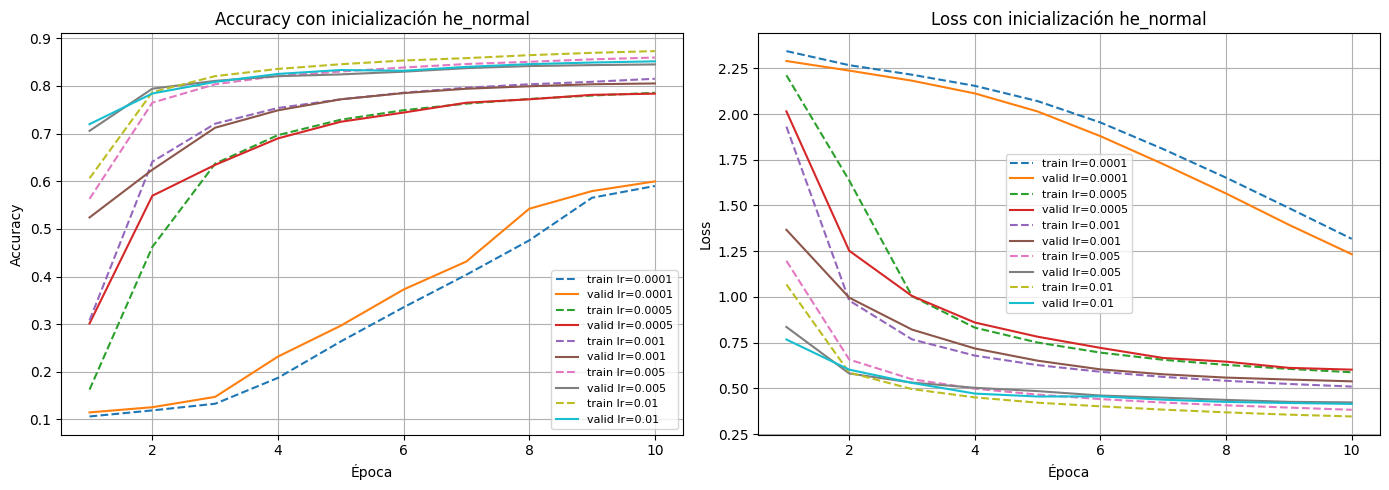

In [9]:
# 5a.
he_histories = {}
he_results = []

for learning_rate in learning_rates:
    keras.utils.set_random_seed(42)

    he_model = fully_connected_model(
        input_shape=X_train.shape[1:],
        n_hiddens=20,
        n_neurons=100,
        activation="relu",
        optimizer="sgd",
        learning_rate=learning_rate,
        kernel_initializer="he_normal",
    )

    print(f"Entrenando modelo con he_normal y learning_rate={learning_rate:g}")
    history = he_model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=128,
        validation_data=(X_valid, y_valid),
        verbose=0,
    )

    he_histories[learning_rate] = history
    he_results.append(
        {
            "learning_rate": learning_rate,
            "train_loss": history.history["loss"][-1],
            "train_accuracy": history.history["accuracy"][-1],
            "valid_loss": history.history["val_loss"][-1],
            "valid_accuracy": history.history["val_accuracy"][-1],
        }
    )

he_results_df = pd.DataFrame(he_results).sort_values(
    "valid_accuracy",
    ascending=False,
)
best_he_learning_rate = he_results_df.iloc[0]["learning_rate"]

display(he_results_df)
print(f"Mejor learning rate con he_normal: {best_he_learning_rate:g}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for learning_rate, history in he_histories.items():
    epochs = range(1, len(history.history["accuracy"]) + 1)
    label = f"lr={learning_rate:g}"

    axes[0].plot(epochs, history.history["accuracy"], linestyle="--", label=f"train {label}")
    axes[0].plot(epochs, history.history["val_accuracy"], label=f"valid {label}")

    axes[1].plot(epochs, history.history["loss"], linestyle="--", label=f"train {label}")
    axes[1].plot(epochs, history.history["val_loss"], label=f"valid {label}")

axes[0].set_title("Accuracy con inicialización he_normal")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")

axes[1].set_title("Loss con inicialización he_normal")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")

for ax in axes:
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

,learning_rate,glorot_train_loss,glorot_train_accuracy,glorot_valid_loss,glorot_valid_accuracy,he_train_loss,he_train_accuracy,he_valid_loss,he_valid_accuracy,delta_valid_accuracy,delta_valid_loss
2,0.0001,2.302424,0.18468,2.302415,0.1997,1.317714,0.59008,1.233693,0.5997,0.4000,-1.068723
3,0.0005,2.301950,0.12236,2.301945,0.1075,0.588408,0.78572,0.602756,0.7839,0.6764,-1.699190
4,0.0010,2.301061,0.10254,2.300920,0.0942,0.510254,0.81514,0.538809,0.8053,0.7111,-1.762111
1,0.0050,1.462562,0.46026,1.203407,0.5649,0.383292,0.85968,0.423545,0.8452,0.2803,-0.779862
0,0.0100,0.715160,0.72170,0.679176,0.7439,0.346859,0.87320,0.415309,0.8517,0.1078,-0.263867


Mejor combinación: he_normal, learning_rate=0.01, valid_accuracy=0.8517


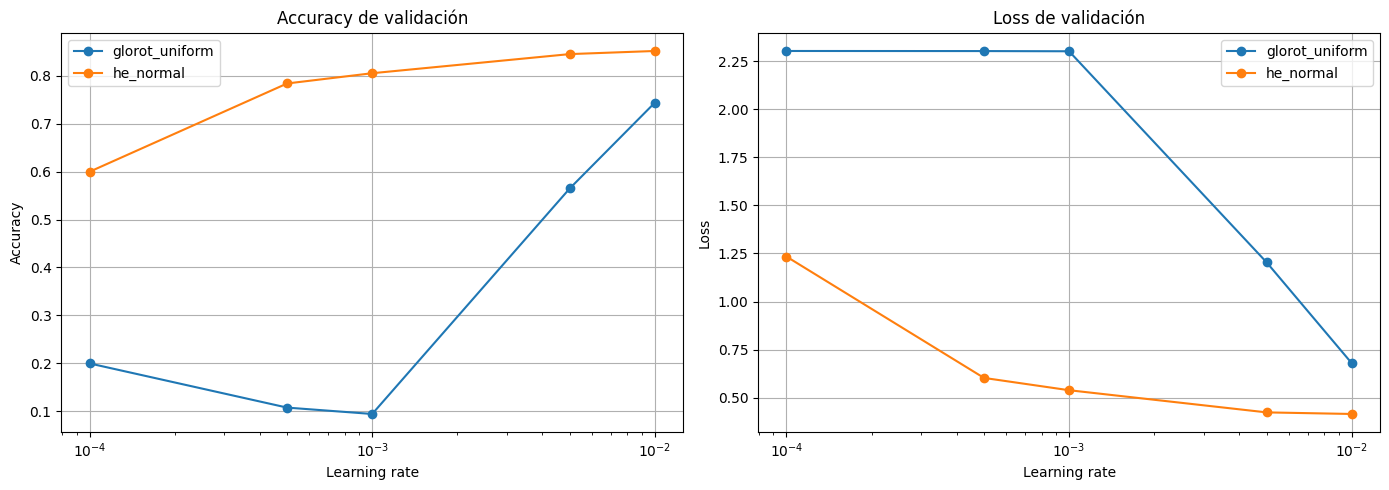

In [10]:
# Codigo de comparacion entre inicializaciones
required_objects = ["part4_results_df", "he_results_df", "part4_histories", "he_histories"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise RuntimeError(
        "Ejecute primero la Parte 4 y la Parte 5a antes de comparar inicializaciones. "
        f"Faltan: {missing_objects}"
    )

glorot_comparison = part4_results_df.copy().rename(
    columns={
        "train_loss": "glorot_train_loss",
        "train_accuracy": "glorot_train_accuracy",
        "valid_loss": "glorot_valid_loss",
        "valid_accuracy": "glorot_valid_accuracy",
    }
)

he_comparison = he_results_df.copy().rename(
    columns={
        "train_loss": "he_train_loss",
        "train_accuracy": "he_train_accuracy",
        "valid_loss": "he_valid_loss",
        "valid_accuracy": "he_valid_accuracy",
    }
)

initialization_comparison_df = glorot_comparison.merge(
    he_comparison,
    on="learning_rate",
).sort_values("learning_rate")

initialization_comparison_df["delta_valid_accuracy"] = (
    initialization_comparison_df["he_valid_accuracy"]
    - initialization_comparison_df["glorot_valid_accuracy"]
)
initialization_comparison_df["delta_valid_loss"] = (
    initialization_comparison_df["he_valid_loss"]
    - initialization_comparison_df["glorot_valid_loss"]
)

display(initialization_comparison_df)

best_initialization_row = initialization_comparison_df.loc[
    initialization_comparison_df[
        ["glorot_valid_accuracy", "he_valid_accuracy"]
    ].max(axis=1).idxmax()
]

if best_initialization_row["he_valid_accuracy"] >= best_initialization_row["glorot_valid_accuracy"]:
    best_initializer = "he_normal"
    best_initializer_accuracy = best_initialization_row["he_valid_accuracy"]
else:
    best_initializer = "glorot_uniform"
    best_initializer_accuracy = best_initialization_row["glorot_valid_accuracy"]

print(
    "Mejor combinación: "
    f"{best_initializer}, learning_rate={best_initialization_row['learning_rate']:g}, "
    f"valid_accuracy={best_initializer_accuracy:.4f}"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    initialization_comparison_df["learning_rate"],
    initialization_comparison_df["glorot_valid_accuracy"],
    marker="o",
    label="glorot_uniform",
)
axes[0].plot(
    initialization_comparison_df["learning_rate"],
    initialization_comparison_df["he_valid_accuracy"],
    marker="o",
    label="he_normal",
)
axes[0].set_title("Accuracy de validación")
axes[0].set_xlabel("Learning rate")
axes[0].set_ylabel("Accuracy")

axes[1].plot(
    initialization_comparison_df["learning_rate"],
    initialization_comparison_df["glorot_valid_loss"],
    marker="o",
    label="glorot_uniform",
)
axes[1].plot(
    initialization_comparison_df["learning_rate"],
    initialization_comparison_df["he_valid_loss"],
    marker="o",
    label="he_normal",
)
axes[1].set_title("Loss de validación")
axes[1].set_xlabel("Learning rate")
axes[1].set_ylabel("Loss")

for ax in axes:
    ax.set_xscale("log")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

#### Observación

La inicialización `he_normal` mejora claramente frente a la inicialización por defecto `glorot_uniform` en todos los valores de *learning rate* probados. La diferencia es especialmente grande para `1e-4`, `5e-4` y `1e-3`, con `glorot_uniform` la red casi no aprende, mientras que con `he_normal` logra avanzar desde las primeras épocas.

Esto es coherente, la red tiene muchas capas ocultas y usa activación `relu`, por lo que una inicialización pensada para ReLU ayuda a preservar mejor la escala de las activaciones y los gradientes.

El mejor resultado observado en validación es con `he_normal` y `learning_rate=1e-2`, con validación de `0.85`. Con esto, cambiar la inicialización tiene un impacto mayor que ajustar levemente el *learning rate*.


### Observacion

ACA

**5b) (opcional):** Probar otras formas de inicialización. Por ejemplo, ¿Qué pasa si se utiliza 'random_normal'?

Entrenando modelo con random_normal y learning_rate=0.01


I0000 00:00:1780856059.249611   10777 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_214542__.31
I0000 00:00:1780856062.624798   10777 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_214542__.31


Entrenando modelo con glorot_normal y learning_rate=0.01


I0000 00:00:1780856095.326870   10780 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_235768__.31
I0000 00:00:1780856099.064022   10781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_235768__.31


Entrenando modelo con he_uniform y learning_rate=0.01


I0000 00:00:1780856131.217338   10777 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_257014__.31
I0000 00:00:1780856135.007882   10781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_257014__.31


,initializer,learning_rate,train_loss,train_accuracy,valid_loss,valid_accuracy
2,he_uniform,0.01,0.348418,0.87182,0.421784,0.8543
1,glorot_normal,0.01,0.620365,0.78188,0.591990,0.7990
0,random_normal,0.01,2.302608,0.10116,2.302709,0.0942


Mejor inicialización adicional: he_uniform


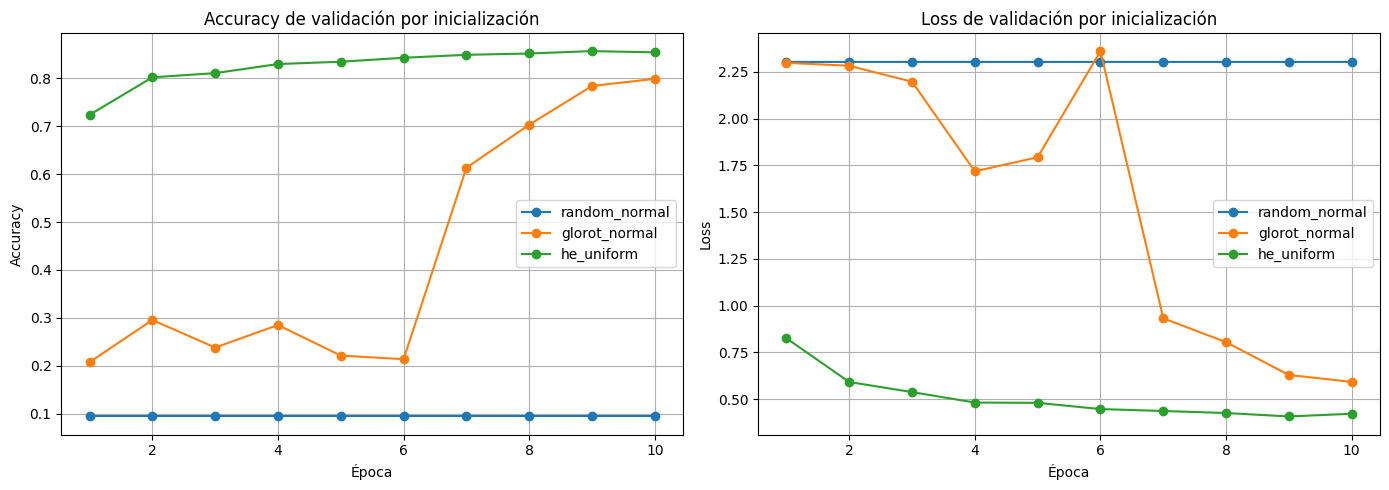

In [12]:
# 5b.
initializers_to_test = ["random_normal", "glorot_normal", "he_uniform"]
initializer_histories = {}
initializer_results = []

comparison_learning_rate = globals().get("best_he_learning_rate", 1e-2)

for initializer in initializers_to_test:
    keras.utils.set_random_seed(42)

    initializer_model = fully_connected_model(
        input_shape=X_train.shape[1:],
        n_hiddens=20,
        n_neurons=100,
        activation="relu",
        optimizer="sgd",
        learning_rate=comparison_learning_rate,
        kernel_initializer=initializer,
    )

    print(
        f"Entrenando modelo con {initializer} "
        f"y learning_rate={comparison_learning_rate:g}"
    )
    history = initializer_model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=128,
        validation_data=(X_valid, y_valid),
        verbose=0,
    )

    initializer_histories[initializer] = history
    initializer_results.append(
        {
            "initializer": initializer,
            "learning_rate": comparison_learning_rate,
            "train_loss": history.history["loss"][-1],
            "train_accuracy": history.history["accuracy"][-1],
            "valid_loss": history.history["val_loss"][-1],
            "valid_accuracy": history.history["val_accuracy"][-1],
        }
    )

initializer_results_df = pd.DataFrame(initializer_results).sort_values(
    "valid_accuracy",
    ascending=False,
)
best_extra_initializer = initializer_results_df.iloc[0]["initializer"]

display(initializer_results_df)
print(f"Mejor inicialización adicional: {best_extra_initializer}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for initializer, history in initializer_histories.items():
    epochs = range(1, len(history.history["accuracy"]) + 1)
    axes[0].plot(epochs, history.history["val_accuracy"], marker="o", label=initializer)
    axes[1].plot(epochs, history.history["val_loss"], marker="o", label=initializer)

axes[0].set_title("Accuracy de validación por inicialización")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")

axes[1].set_title("Loss de validación por inicialización")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")

for ax in axes:
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

#### Otras inicializaciones

- `random_normal` usa una escala fija y no toma en cuenta la cantidad de entradas de cada capa, por lo que puede funcionar peor en redes profundas.
- `glorot_normal` es una variante de la inicialización por defecto, pero usando distribución normal en lugar de uniforme.
- `he_uniform` es la versión uniforme de He y, al igual que `he_normal`, está pensada para capas con activación `relu`.

Si `he_uniform` obtiene resultados similares o mejores que `he_normal`, eso refuerza la idea de que para esta red profunda con `relu` conviene usar inicializaciones de la familia He. `Random_normal` queda por detrás, mostrando que no alcanza con inicializar aleatoriamente, la escala de los pesos iniciales también importa.


### Parte 6 - Batch Normalization

Modifique la implementación de la función *fully_connected_model* para que admita la posibilidad de agregar capas de *batch normalization*. En caso de utilizar *batch normalization* coloque dichas capas luego de las capas densas y antes de las activaciones, tal como fue propuesto en el [paper original](https://arxiv.org/pdf/1502.03167.pdf). 

## Resumen del paper original

El paper propone **Batch Normalization** para reducir el *internal covariate shift*: durante el entrenamiento, las capas anteriores cambian sus pesos y eso cambia la distribución de las entradas que reciben las capas siguientes. Esa inestabilidad puede volver el entrenamiento más lento y sensible al *learning rate* o a la inicialización.

La idea de Batch Normalization es normalizar las activaciones usando la media y varianza del **mini-batch**. Para cada activación se calcula una versión centrada y escalada, aproximadamente con media `0` y varianza `1`. Después se aplican dos parámetros aprendibles, `gamma` y `beta`, que permiten reescalar y desplazar la activación si al modelo le conviene.

En entrenamiento, las estadísticas salen del mini-batch actual. En inferencia, no se usa el mini-batch, sino medias y varianzas acumuladas durante el entrenamiento, para que la predicción sea determinística.

Según los autores, esto permite entrenar más rápido, usar *learning rates* más altos, depender menos de una inicialización perfecta y, a veces, actuar como regularizador. En una red como la nuestra, se coloca típicamente después de la capa `Dense` y antes de la activación.


**6a)** ¿Cuántos parámetros tiene el modelo con *batch normalization*? ¿Qué son y para que se usan los *Non-trainable-parameters*?

In [16]:
model_bn = fully_connected_model(
    input_shape=X_train.shape[1:],
    n_hiddens=20,
    n_neurons=100,
    activation="relu",
    optimizer="sgd",
    learning_rate=1e-3,
    kernel_initializer="glorot_uniform",
    use_batch_norm=True,
)

model_bn.summary()

print(f"Total params: {model_bn.count_params():,}")
print(f"Trainable params: {sum(np.prod(var.shape) for var in model_bn.trainable_weights):,}")
print(f"Non-trainable params: {sum(np.prod(var.shape) for var in model_bn.non_trainable_weights):,}")

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_15 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_315 (Dense)               │ (None, 100)            │        78,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_316 (Dense)               │ (None, 100)            │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_317 (Dense)               │ (None, 100)            │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_318 (Dense)               │ (None, 100)            │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_319 (Dense)               │ (None, 100)            │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_320 (Dense)               │ (None, 100)            │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_321 (Dense)               │ (None, 100)            │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 277,410 (1.06 MB)

 Trainable params: 273,410 (1.04 MB)

 Non-trainable params: 4,000 (15.62 KB)

Total params: 277,410
Trainable params: 273,410
Non-trainable params: 4,000


#### Observación sobre los parámetros de Batch Normalization

Cada capa `BatchNormalization` agrega cuatro valores por neurona: `gamma`, `beta`, `moving_mean` y `moving_variance`.

- `gamma` y `beta` son **trainable params**: el modelo los aprende para reescalar y desplazar las activaciones normalizadas.
- `moving_mean` y `moving_variance` son **non-trainable params**: no se optimizan por gradiente, sino que se actualizan como promedios móviles durante el entrenamiento.


**6b)** Repita el experimento de la **parte 4** pero ahora utilizando el modelo con *batch normalization*. Para este experimento vuelva a la inicialización de los pesos por defecto ('glorot_uniform').

Entrenando modelo con Batch Normalization y learning_rate=0.0001


I0000 00:00:1780857243.811374   10778 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_283380__.131
I0000 00:00:1780857244.007102   10778 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780857244.696435   31672 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_40', 52 bytes spill stores, 52 bytes spill loads

I0000 00:00:1780857244.854492   10778 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780857250.932107   10780 dot_merger.cc:481] Merging Dots in computation: a_inference_one

Entrenando modelo con Batch Normalization y learning_rate=0.0005


I0000 00:00:1780857293.285629   10778 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_308986__.131
I0000 00:00:1780857298.455785   10781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_308986__.131


Entrenando modelo con Batch Normalization y learning_rate=0.001


...

I0000 00:00:1780857388.934361   10780 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_360198__.131
I0000 00:00:1780857393.912506   10777 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_360198__.131


Entrenando modelo con Batch Normalization y learning_rate=0.01


I0000 00:00:1780857429.107165   10780 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_385804__.131
I0000 00:00:1780857433.194192   10780 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_385804__.131


,learning_rate,train_accuracy,valid_accuracy,train_loss,valid_loss
0,0.0100,0.87124,0.8371,0.365707,0.454647
1,0.0050,0.85338,0.8342,0.425967,0.482553
2,0.0010,0.73848,0.7374,0.761484,0.742919
3,0.0005,0.61884,0.6464,1.173300,1.074138
4,0.0001,0.16390,0.1679,2.319618,2.304857


Mejor learning rate con Batch Normalization: 0.01


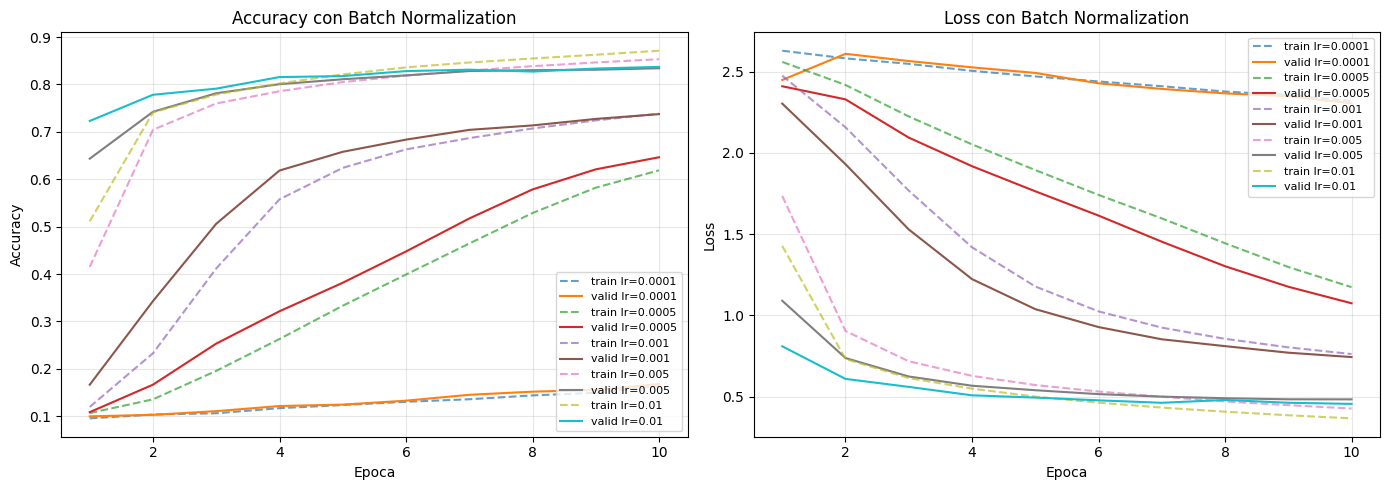

In [17]:
# 6b.
if "learning_rates" not in globals():
    raise RuntimeError("Ejecute primero la parte 4 para definir learning_rates.")

batch_norm_histories = {}
batch_norm_results = []

for learning_rate in learning_rates:
    keras.utils.set_random_seed(42)
    batch_norm_model = fully_connected_model(
        input_shape=X_train.shape[1:],
        n_hiddens=20,
        n_neurons=100,
        activation="relu",
        optimizer="sgd",
        learning_rate=learning_rate,
        kernel_initializer="glorot_uniform",
        use_batch_norm=True,
    )

    print(f"Entrenando modelo con Batch Normalization y learning_rate={learning_rate:g}")
    history = batch_norm_model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=128,
        validation_data=(X_valid, y_valid),
        verbose=0,
    )

    batch_norm_histories[learning_rate] = history
    batch_norm_results.append(
        {
            "learning_rate": learning_rate,
            "train_accuracy": history.history["accuracy"][-1],
            "valid_accuracy": history.history["val_accuracy"][-1],
            "train_loss": history.history["loss"][-1],
            "valid_loss": history.history["val_loss"][-1],
        }
    )

batch_norm_results_df = (
    pd.DataFrame(batch_norm_results)
    .sort_values("valid_accuracy", ascending=False)
    .reset_index(drop=True)
)
best_batch_norm_learning_rate = batch_norm_results_df.loc[0, "learning_rate"]

display(batch_norm_results_df)
print(f"Mejor learning rate con Batch Normalization: {best_batch_norm_learning_rate:g}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for learning_rate, history in batch_norm_histories.items():
    epochs = range(1, len(history.history["accuracy"]) + 1)
    label = f"lr={learning_rate:g}"
    axes[0].plot(epochs, history.history["accuracy"], linestyle="--", alpha=0.7, label=f"train {label}")
    axes[0].plot(epochs, history.history["val_accuracy"], label=f"valid {label}")
    axes[1].plot(epochs, history.history["loss"], linestyle="--", alpha=0.7, label=f"train {label}")
    axes[1].plot(epochs, history.history["val_loss"], label=f"valid {label}")

axes[0].set_title("Accuracy con Batch Normalization")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_title("Loss con Batch Normalization")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Observación sobre Batch Normalization

Con `glorot_uniform`, Batch Normalization mejora claramente el experimento de la parte 4. El mejor `learning_rate` sigue siendo `0.01`, pero la accuracy de validación sube de aproximadamente `0.7439` a `0.8371`.

También se ve que los learning rates chicos dejan de quedar tan estancados: por ejemplo, `0.001` pasa de un comportamiento casi aleatorio a una accuracy de validación cercana a `0.7374`. Esto es coherente con la idea de Batch Normalization: al estabilizar las activaciones intermedias, el entrenamiento de una red profunda se vuelve menos sensible a la escala de los pesos y al learning rate.

De todos modos, en estas corridas el mejor resultado con Batch Normalization (`0.8371`) queda un poco por debajo del mejor resultado obtenido con `he_normal` (`0.8517`).

### Parte 7 -  Optimizador

**Parte 7a)** De ser necesario, modifique la implementación de la función `fully_connected_model()` para que permita optimizar utilizando el método *adam*. Repita el experimento de la **parte 4** pero modificando solamente el optimizador. Comente los cambios que observa.

Entrenando modelo con Adam y learning_rate=0.0001


I0000 00:00:1780857999.682504   10781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_412422__.31
I0000 00:00:1780857999.730807   10781 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780858000.281300   39689 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_40', 88 bytes spill stores, 88 bytes spill loads

I0000 00:00:1780858004.916453   10777 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_412422__.31
I0000 00:00:1780858004.988694   10777 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the

Entrenando modelo con Adam y learning_rate=0.0005


I0000 00:00:1780858038.743945   10779 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_438708__.31
I0000 00:00:1780858043.053432   10780 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_438708__.31


Entrenando modelo con Adam y learning_rate=0.001


...

I0000 00:00:1780858114.993710   10781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_491280__.31
I0000 00:00:1780858122.427666   10778 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_491280__.31


Entrenando modelo con Adam y learning_rate=0.01


I0000 00:00:1780858160.824549   10781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_517566__.31
I0000 00:00:1780858165.338547   10780 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_517566__.31


,learning_rate,train_accuracy,valid_accuracy,train_loss,valid_loss
0,0.0005,0.88744,0.8788,0.317044,0.350054
1,0.0010,0.86360,0.8397,0.398712,0.478338
2,0.0001,0.84382,0.8326,0.423687,0.457429
3,0.0050,0.65780,0.7422,0.846414,0.730627
4,0.0100,0.10178,0.1016,2.303278,2.302901


Mejor learning rate con Adam: 0.0005


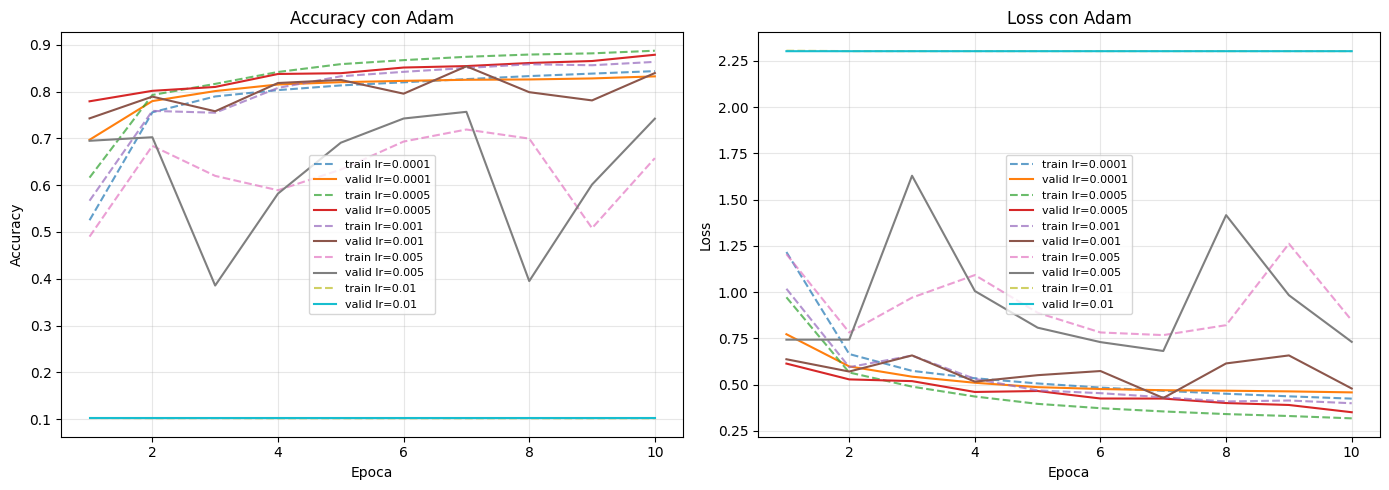

In [18]:
# 7a.
if "learning_rates" not in globals():
    raise RuntimeError("Ejecute primero la parte 4 para definir learning_rates.")

adam_histories = {}
adam_results = []

for learning_rate in learning_rates:
    keras.utils.set_random_seed(42)
    adam_model = fully_connected_model(
        input_shape=X_train.shape[1:],
        n_hiddens=20,
        n_neurons=100,
        activation="relu",
        optimizer="adam",
        learning_rate=learning_rate,
        kernel_initializer="glorot_uniform",
        use_batch_norm=False,
    )

    print(f"Entrenando modelo con Adam y learning_rate={learning_rate:g}")
    history = adam_model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=128,
        validation_data=(X_valid, y_valid),
        verbose=0,
    )

    adam_histories[learning_rate] = history
    adam_results.append(
        {
            "learning_rate": learning_rate,
            "train_accuracy": history.history["accuracy"][-1],
            "valid_accuracy": history.history["val_accuracy"][-1],
            "train_loss": history.history["loss"][-1],
            "valid_loss": history.history["val_loss"][-1],
        }
    )

adam_results_df = (
    pd.DataFrame(adam_results)
    .sort_values("valid_accuracy", ascending=False)
    .reset_index(drop=True)
)
best_adam_learning_rate = adam_results_df.loc[0, "learning_rate"]

display(adam_results_df)
print(f"Mejor learning rate con Adam: {best_adam_learning_rate:g}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for learning_rate, history in adam_histories.items():
    epochs = range(1, len(history.history["accuracy"]) + 1)
    label = f"lr={learning_rate:g}"
    axes[0].plot(epochs, history.history["accuracy"], linestyle="--", alpha=0.7, label=f"train {label}")
    axes[0].plot(epochs, history.history["val_accuracy"], label=f"valid {label}")
    axes[1].plot(epochs, history.history["loss"], linestyle="--", alpha=0.7, label=f"train {label}")
    axes[1].plot(epochs, history.history["val_loss"], label=f"valid {label}")

axes[0].set_title("Accuracy con Adam")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_title("Loss con Adam")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Observación sobre Adam

Para esta parte no fue necesario modificar `fully_connected_model()`, porque la función ya permite pasar `optimizer="adam"` mediante `keras.optimizers.get(optimizer)`. El cambio del experimento fue dejar la arquitectura igual que en la parte 4 y cambiar solamente el optimizador de SGD a Adam.

Con Adam, el mejor resultado se obtiene con `learning_rate=0.0005`, alcanzando una accuracy de validación de aproximadamente `0.8788`. Esto mejora bastante al mejor resultado de la parte 4 con SGD y `glorot_uniform`, que era aproximadamente `0.7439` con `learning_rate=0.01`.

También se observa que Adam necesita learning rates más chicos que SGD. Con `0.0001`, `0.0005` y `0.001` aprende bien, pero con `0.005` baja el rendimiento y con `0.01` queda prácticamente en azar (`valid_accuracy` cercana a `0.10`). Esto pasa porque Adam adapta el paso por parámetro; si además se usa un learning rate global demasiado grande, el entrenamiento puede volverse inestable.

**Parte 7b)** ¿Cambian los resultados del entrenamiento si en la parte anterior además de cambiar el optimizador se agrega *batch normalization* ?

Entrenando modelo con Adam + Batch Normalization y learning_rate=0.0001


I0000 00:00:1780859791.447105   10780 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_549952__.131
I0000 00:00:1780859791.558285   10780 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780859792.361303   52864 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_40', 48 bytes spill stores, 48 bytes spill loads

I0000 00:00:1780859799.030525   10781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_549952__.131
I0000 00:00:1780859799.181405   10781 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using t

Entrenando modelo con Adam + Batch Normalization y learning_rate=0.0005


I0000 00:00:1780859847.798895   10780 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_582918__.131
I0000 00:00:1780859857.550755   10781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_582918__.131


Entrenando modelo con Adam + Batch Normalization y learning_rate=0.001


...

Entrenando modelo con Adam + Batch Normalization y learning_rate=0.01


I0000 00:00:1780860006.168887   10778 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_681816__.131
I0000 00:00:1780860011.582237   10777 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_681816__.131


,learning_rate,train_accuracy,valid_accuracy,train_loss,valid_loss
0,0.0005,0.88598,0.8645,0.315429,0.403017
1,0.0010,0.89170,0.8544,0.306206,0.459056
2,0.0050,0.87970,0.8275,0.352430,0.987429
3,0.0001,0.81812,0.8006,0.506184,0.553350
4,0.0100,0.87658,0.7854,0.363336,1.263468


Mejor learning rate con Adam + Batch Normalization: 0.0005


,learning_rate,adam_train_accuracy,adam_valid_accuracy,adam_train_loss,adam_valid_loss,adam_bn_train_accuracy,adam_bn_valid_accuracy,adam_bn_train_loss,adam_bn_valid_loss,delta_valid_accuracy,delta_valid_loss
0,0.0001,0.84382,0.8326,0.423687,0.457429,0.81812,0.8006,0.506184,0.553350,-0.0320,0.095921
1,0.0005,0.88744,0.8788,0.317044,0.350054,0.88598,0.8645,0.315429,0.403017,-0.0143,0.052963
2,0.0010,0.86360,0.8397,0.398712,0.478338,0.89170,0.8544,0.306206,0.459056,0.0147,-0.019282
3,0.0050,0.65780,0.7422,0.846414,0.730627,0.87970,0.8275,0.352430,0.987429,0.0853,0.256801
4,0.0100,0.10178,0.1016,2.303278,2.302901,0.87658,0.7854,0.363336,1.263468,0.6838,-1.039433


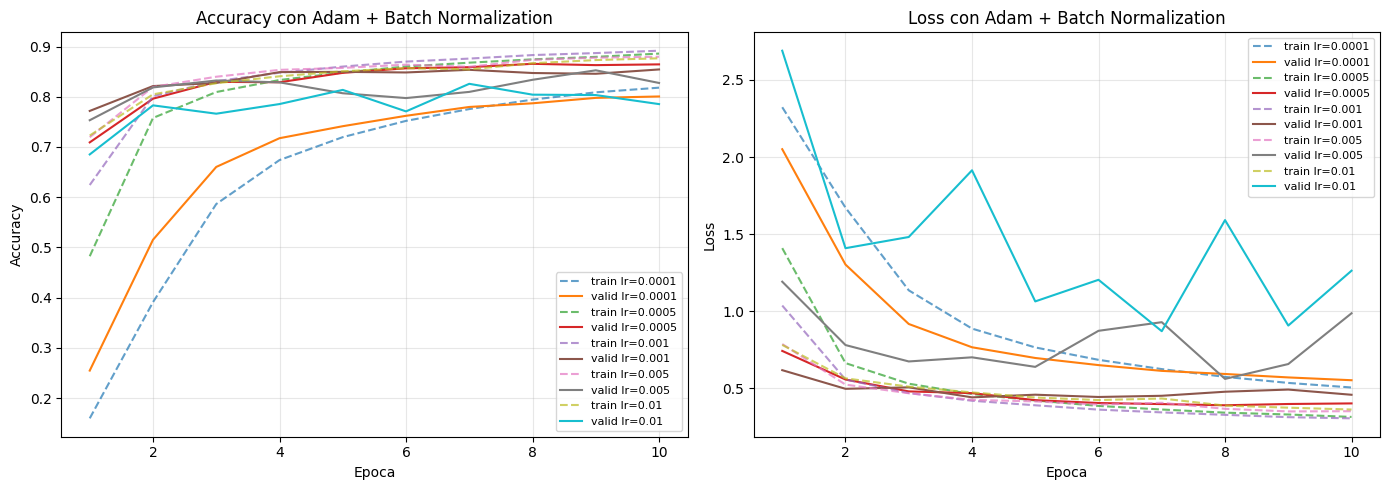

In [19]:
# 7b.
if "learning_rates" not in globals():
    raise RuntimeError("Ejecute primero la parte 4 para definir learning_rates.")

adam_batch_norm_histories = {}
adam_batch_norm_results = []

for learning_rate in learning_rates:
    keras.utils.set_random_seed(42)
    adam_batch_norm_model = fully_connected_model(
        input_shape=X_train.shape[1:],
        n_hiddens=20,
        n_neurons=100,
        activation="relu",
        optimizer="adam",
        learning_rate=learning_rate,
        kernel_initializer="glorot_uniform",
        use_batch_norm=True,
    )

    print(f"Entrenando modelo con Adam + Batch Normalization y learning_rate={learning_rate:g}")
    history = adam_batch_norm_model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=128,
        validation_data=(X_valid, y_valid),
        verbose=0,
    )

    adam_batch_norm_histories[learning_rate] = history
    adam_batch_norm_results.append(
        {
            "learning_rate": learning_rate,
            "train_accuracy": history.history["accuracy"][-1],
            "valid_accuracy": history.history["val_accuracy"][-1],
            "train_loss": history.history["loss"][-1],
            "valid_loss": history.history["val_loss"][-1],
        }
    )

adam_batch_norm_results_df = (
    pd.DataFrame(adam_batch_norm_results)
    .sort_values("valid_accuracy", ascending=False)
    .reset_index(drop=True)
)
best_adam_batch_norm_learning_rate = adam_batch_norm_results_df.loc[0, "learning_rate"]

display(adam_batch_norm_results_df)
print(f"Mejor learning rate con Adam + Batch Normalization: {best_adam_batch_norm_learning_rate:g}")

if "adam_results_df" in globals():
    adam_batch_norm_comparison_df = (
        adam_results_df.rename(
            columns={
                "train_accuracy": "adam_train_accuracy",
                "valid_accuracy": "adam_valid_accuracy",
                "train_loss": "adam_train_loss",
                "valid_loss": "adam_valid_loss",
            }
        )
        .merge(
            adam_batch_norm_results_df.rename(
                columns={
                    "train_accuracy": "adam_bn_train_accuracy",
                    "valid_accuracy": "adam_bn_valid_accuracy",
                    "train_loss": "adam_bn_train_loss",
                    "valid_loss": "adam_bn_valid_loss",
                }
            ),
            on="learning_rate",
        )
        .assign(
            delta_valid_accuracy=lambda df: df["adam_bn_valid_accuracy"] - df["adam_valid_accuracy"],
            delta_valid_loss=lambda df: df["adam_bn_valid_loss"] - df["adam_valid_loss"],
        )
        .sort_values("learning_rate")
        .reset_index(drop=True)
    )
    display(adam_batch_norm_comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for learning_rate, history in adam_batch_norm_histories.items():
    epochs = range(1, len(history.history["accuracy"]) + 1)
    label = f"lr={learning_rate:g}"
    axes[0].plot(epochs, history.history["accuracy"], linestyle="--", alpha=0.7, label=f"train {label}")
    axes[0].plot(epochs, history.history["val_accuracy"], label=f"valid {label}")
    axes[1].plot(epochs, history.history["loss"], linestyle="--", alpha=0.7, label=f"train {label}")
    axes[1].plot(epochs, history.history["val_loss"], label=f"valid {label}")

axes[0].set_title("Accuracy con Adam + Batch Normalization")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_title("Loss con Adam + Batch Normalization")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Observación sobre Adam + Batch Normalization

Los resultados cambian al agregar Batch Normalization junto con Adam. El mejor `learning_rate` sigue siendo `0.0005`, pero la mejor accuracy de validación baja levemente: con Adam solo fue aproximadamente `0.8788`, mientras que con Adam + Batch Normalization fue `0.8645`.

Sin embargo, Batch Normalization hace que los learning rates más grandes sean mucho más estables. Con Adam solo, `learning_rate=0.01` quedó prácticamente en azar (`valid_accuracy ≈ 0.1016`), mientras que con Adam + Batch Normalization subió a aproximadamente `0.7854`. También mejora `0.005`, pasando de `0.7422` a `0.8275`.


### Parte 8  -  Red Neuronal Convolucional

**8a)** Escribir una función similar a la de la **parte 3** pero que construya una red neuronal convolucional con la siguiente arquitectura:
    
N * [Conv2D --> Conv2D --> Pool2D] → Flatten → Dense → Dense. 

donde *N* representa la cantidad de bloques [Conv2D --> Conv2D --> Pool2D] a utilizar. 

In [23]:
# 8a.
def convolutional_model(
    input_shape,
    n_blocks,
    conv1_filters,
    conv2_filters,
    kernel_size=3,
    dense_neurons=128,
    activation="relu",
    optimizer="adam",
    learning_rate=1e-3,
    kernel_initializer="glorot_uniform",
):
    """
    Entrada:
        input_shape: forma de entrada de cada imagen, por ejemplo (28, 28, 1).
        n_blocks: cantidad de bloques Conv2D -> Conv2D -> Pool2D.
        conv1_filters: cantidad de filtros en la primera convolución de cada bloque.
        conv2_filters: cantidad de filtros en la segunda convolución de cada bloque.
        kernel_size: tamaño del filtro de convolución.
        dense_neurons: cantidad de neuronas en la capa densa oculta.
        activation: función de activación.
        optimizer: método de optimización.
        learning_rate: tasa de aprendizaje del optimizador.
        kernel_initializer: inicialización de pesos.
    Salida:
        model: modelo convolucional compilado.
    """

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=input_shape))

    for _ in range(n_blocks):
        model.add(
            keras.layers.Conv2D(
                filters=conv1_filters,
                kernel_size=kernel_size,
                activation=activation,
                padding="same",
                kernel_initializer=kernel_initializer,
            )
        )
        model.add(
            keras.layers.Conv2D(
                filters=conv2_filters,
                kernel_size=kernel_size,
                activation=activation,
                padding="same",
                kernel_initializer=kernel_initializer,
            )
        )
        model.add(keras.layers.MaxPooling2D(pool_size=2))

    model.add(keras.layers.Flatten())
    model.add(
        keras.layers.Dense(
            dense_neurons,
            activation=activation,
            kernel_initializer=kernel_initializer,
        )
    )
    model.add(keras.layers.Dense(10, activation="softmax"))

    optimizer_instance = keras.optimizers.get(optimizer)
    optimizer_instance.learning_rate = learning_rate

    model.compile(
        optimizer=optimizer_instance,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

**8b)** Entrenar una realización de la red. Por ejemplo, utilizar:
- N=2
- 64 filtros de convolución de tamaño 3 en la primera capa del bloque
- 32 filtros de convolución de tamaño 3 en la segunda capa del bloque
- 128 neuronas en la primera capa densa 

Epoch 1/10


I0000 00:00:1780861187.330380   10781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_727231__.32


387/391 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6866 - loss: 0.8907

I0000 00:00:1780861192.724644   10779 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_727231__.32


391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7922 - loss: 0.5785 - val_accuracy: 0.8668 - val_loss: 0.3748
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8763 - loss: 0.3418 - val_accuracy: 0.8863 - val_loss: 0.3143
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8957 - loss: 0.2846 - val_accuracy: 0.9006 - val_loss: 0.2776
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9087 - loss: 0.2481 - val_accuracy: 0.9077 - val_loss: 0.2537
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9186 - loss: 0.2222 - val_accuracy: 0.9136 - val_loss: 0.2362
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9269 - loss: 0.2007 - val_accuracy: 0.9166 - val_loss: 0.2236
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9337 - loss: 0.1827 - val_accuracy: 0.9212 - val_loss: 0.2158
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9405 - loss: 0.1662 - val_accuracy: 0.9212 - v

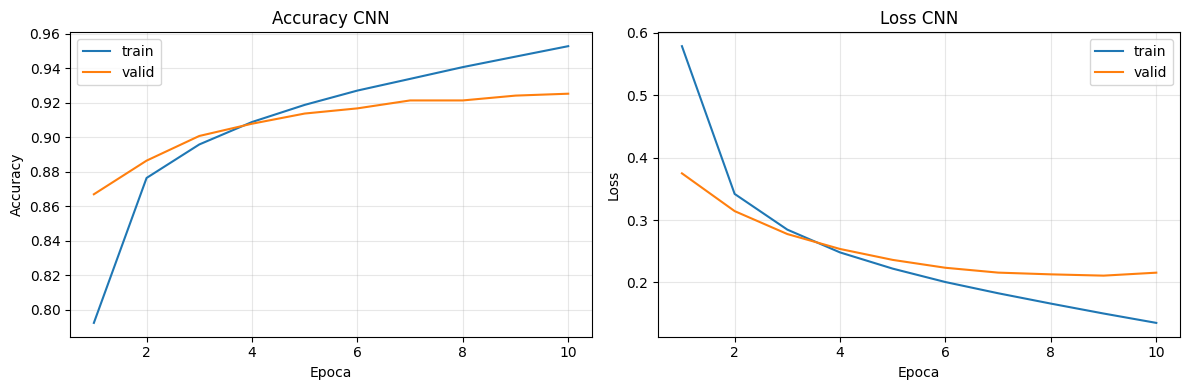

In [24]:
# 8b.
def add_channel_axis(images):
    if images.ndim == 3:
        return images[..., np.newaxis]
    return images

X_train_cnn = add_channel_axis(X_train)
X_valid_cnn = add_channel_axis(X_valid)
X_test_cnn = add_channel_axis(X_test)

cnn_learning_rate = globals().get("best_adam_learning_rate", 5e-4)

keras.utils.set_random_seed(42)
cnn_model = convolutional_model(
    input_shape=X_train_cnn.shape[1:],
    n_blocks=2,
    conv1_filters=64,
    conv2_filters=32,
    kernel_size=3,
    dense_neurons=128,
    activation="relu",
    optimizer="adam",
    learning_rate=cnn_learning_rate,
    kernel_initializer="glorot_uniform",
)

cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_valid_cnn, y_valid),
    verbose=1,
)

cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Test accuracy CNN: {cnn_test_accuracy:.4f}")
print(f"Test loss CNN: {cnn_test_loss:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(cnn_history.history["accuracy"]) + 1)

axes[0].plot(epochs, cnn_history.history["accuracy"], label="train")
axes[0].plot(epochs, cnn_history.history["val_accuracy"], label="valid")
axes[0].set_title("Accuracy CNN")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, cnn_history.history["loss"], label="train")
axes[1].plot(epochs, cnn_history.history["val_loss"], label="valid")
axes[1].set_title("Loss CNN")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

El entrenamiento mejoró de forma sostenida: la accuracy de validación pasó de `0.8668` en la primera época a `0.9251` en la época 10. En test, el modelo obtuvo `accuracy = 0.9204` y `loss = 0.2343`, que es mejor que los modelos densos probados antes.

**8c)** ¿Cuántos parámetros tiene el modelo?

In [25]:
# 8c.
cnn_model.summary()

cnn_total_params = cnn_model.count_params()
cnn_trainable_params = sum(np.prod(variable.shape) for variable in cnn_model.trainable_variables)
cnn_non_trainable_params = sum(np.prod(variable.shape) for variable in cnn_model.non_trainable_variables)

print(f"Parametros totales: {cnn_total_params:,}")
print(f"Parametros entrenables: {cnn_trainable_params:,}")
print(f"Parametros no entrenables: {cnn_non_trainable_params:,}")

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_32 (Flatten)            │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_653 (Dense)               │ (None, 128)            │       200,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_654 (Dense)               │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 774,560 (2.95 MB)

 Trainable params: 258,186 (1008.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 516,374 (1.97 MB)

Parametros totales: 258,186
Parametros entrenables: 258,186
Parametros no entrenables: 0


#### Respuesta 8c

El modelo convolucional tiene `258,186` parámetros propios, y todos son entrenables. No hay parámetros no entrenables porque esta arquitectura no usa capas como Batch Normalization.

En el `summary()` aparece también `Total params: 774,560` porque Keras incluye los parámetros internos del optimizador Adam después de entrenar. Para responder cuántos parámetros tiene el modelo.

La mayor parte de los parámetros está en la primera capa densa: después de los dos bloques convolucionales queda una salida de `7 x 7 x 32 = 1,568` valores, y la capa densa de `128` neuronas aporta `(1,568 + 1) * 128 = 200,832` parámetros.

### Parte 9 - Entrenar la mejor arquitectura posible

En esta parte el objetivo será entrenar el mejor clasificador posible para *Fashion MNIST*. La única restricción es que el modelo de arquitectura tendrá que ser como el de la **parte 3** o como el de la **parte 8**. En ambos casos se podrán evaluar las siguientes variaciones:     
    - Número de capas y neuronas por capa en el modelo de la **parte3**.     
    - Número de bloques, cantidad de filtros de bloque y tamaño de los filtros en el caso del modelo de la **parte 8**.              
    - Distintas funciones de activación y métodos de inicialización de pesos.     
    - Agregado de *Batch Normalization* y/o *Dropout*.    
    - Distintos métodos de optimización y sus parámetros.     

Para entrenar los modelos se recomienda la utilización de alguno de los [callbacks](https://keras.io/callbacks/) disponibles en *keras*. Por ejemplo: *early stopping* y *model checkpoint*.

In [26]:
# Parte 9 - Modelo candidato
def ensure_channel_axis(images):
    if images.ndim == 3:
        return images[..., np.newaxis]
    return images

X_train_cnn = ensure_channel_axis(X_train)
X_valid_cnn = ensure_channel_axis(X_valid)
X_test_cnn = ensure_channel_axis(X_test)

part9_config = {
    "conv_blocks": [(64, 64), (128, 128), (128, 128)],
    "kernel_size": 3,
    "dense_neurons": 256,
    "dropout_rate": 0.30,
    "activation": "relu",
    "kernel_initializer": "he_normal",
    "learning_rate": 3e-4,
}

def build_part9_cnn_model(
    input_shape,
    conv_blocks,
    kernel_size=3,
    dense_neurons=256,
    dropout_rate=0.30,
    activation="relu",
    kernel_initializer="he_normal",
    learning_rate=3e-4,
):
    model = keras.Sequential(name="part9_best_cnn")
    model.add(keras.layers.Input(shape=input_shape))

    for block_index, (conv1_filters, conv2_filters) in enumerate(conv_blocks, start=1):
        model.add(
            keras.layers.Conv2D(
                conv1_filters,
                kernel_size=kernel_size,
                padding="same",
                use_bias=False,
                kernel_initializer=kernel_initializer,
                name=f"block_{block_index}_conv_1",
            )
        )
        model.add(keras.layers.BatchNormalization(name=f"block_{block_index}_bn_1"))
        model.add(keras.layers.Activation(activation, name=f"block_{block_index}_activation_1"))

        model.add(
            keras.layers.Conv2D(
                conv2_filters,
                kernel_size=kernel_size,
                padding="same",
                use_bias=False,
                kernel_initializer=kernel_initializer,
                name=f"block_{block_index}_conv_2",
            )
        )
        model.add(keras.layers.BatchNormalization(name=f"block_{block_index}_bn_2"))
        model.add(keras.layers.Activation(activation, name=f"block_{block_index}_activation_2"))
        model.add(keras.layers.MaxPooling2D(pool_size=2, name=f"block_{block_index}_pool"))
        model.add(keras.layers.Dropout(dropout_rate, name=f"block_{block_index}_dropout"))

    model.add(keras.layers.Flatten(name="flatten_features"))
    model.add(
        keras.layers.Dense(
            dense_neurons,
            use_bias=False,
            kernel_initializer=kernel_initializer,
            name="dense_hidden",
        )
    )
    model.add(keras.layers.BatchNormalization(name="dense_bn"))
    model.add(keras.layers.Activation(activation, name="dense_activation"))
    model.add(keras.layers.Dropout(dropout_rate, name="dense_dropout"))
    model.add(keras.layers.Dense(10, activation="softmax", name="output"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

keras.utils.set_random_seed(42)
part9_model = build_part9_cnn_model(
    input_shape=X_train_cnn.shape[1:],
    **part9_config,
)

part9_model.summary()

Model: "part9_best_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block_1_conv_1 (Conv2D)         │ (None, 28, 28, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_1_bn_1                    │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_1_activation_1            │ (None, 28, 28, 64)     │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_1_conv_2 (Conv2D)         │ (None, 28, 28, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_1_bn_2                    │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_1_activation_2            │ (None, 28, 28, 64)     │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_1_pool (MaxPooling2D)     │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_1_dropout (Dropout)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_2_conv_1 (Conv2D)         │ (None, 14, 14, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_2_bn_1                    │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_2_activation_1            │ (None, 14, 14, 128)    │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_2_conv_2 (Conv2D)         │ (None, 14, 14, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_2_bn_2                    │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_2_activation_2            │ (None, 14, 14, 128)    │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_2_pool (MaxPooling2D)     │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_2_dropout (Dropout)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_3_conv_1 (Conv2D)         │ (None, 7, 7, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_3_bn_1                    │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_3_activation_1            │ (None, 7, 7, 128)      │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_3_conv_2 (Conv2D)         │ (None, 7, 7, 128)      │       147,45

 Total params: 854,602 (3.26 MB)

 Trainable params: 852,810 (3.25 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/30


I0000 00:00:1780861627.285598   10781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_753161__.81
I0000 00:00:1780861629.474233   68946 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 8 bytes spill stores, 8 bytes spill loads



389/391 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6066 - loss: 1.1160

I0000 00:00:1780861649.492581   10779 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_753161__.81


391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6072 - loss: 1.1142
Epoch 1: val_accuracy improved from None to 0.81800, saving model to models/part9_best_cnn.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.7253 - loss: 0.7578 - val_accuracy: 0.8180 - val_loss: 0.5104 - learning_rate: 3.0000e-04
Epoch 2/30
389/391 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8310 - loss: 0.4575
Epoch 2: val_accuracy improved from 0.81800 to 0.86980, saving model to models/part9_best_cnn.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.8410 - loss: 0.4318 - val_accuracy: 0.8698 - val_loss: 0.3511 - learning_rate: 3.0000e-04
Epoch 3/30
388/391 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8661 - loss: 0.3630
Epoch 3: val_accuracy improved from 0.86980 to 0.89750, saving model to models/part9_best_cnn.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8693 - loss: 0.3549 - val_accuracy: 0.8975 - val_loss: 0.2768 - learning_rate: 3.0000e-04
Epoch 4/30
38

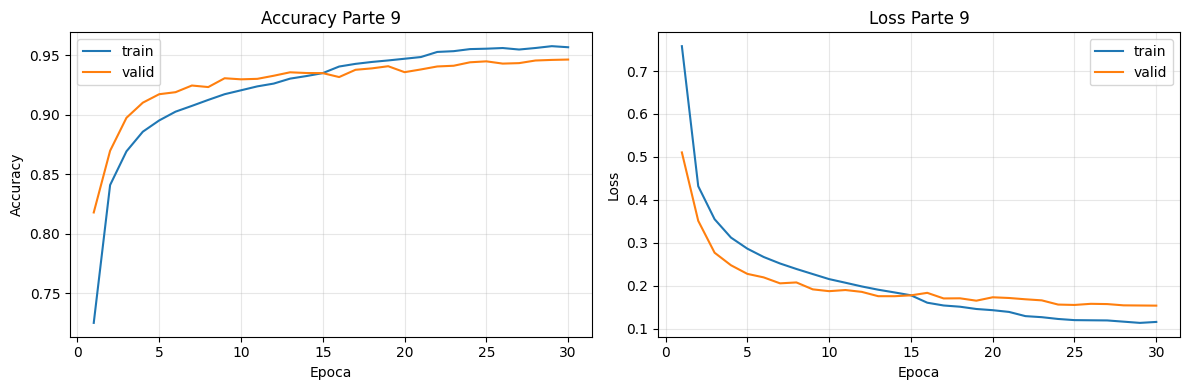

In [27]:
# Parte 9 - Entrenamiento
from pathlib import Path

Path("models").mkdir(exist_ok=True)

part9_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="models/part9_best_cnn.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
]

part9_history = part9_model.fit(
    X_train_cnn,
    y_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_valid_cnn, y_valid),
    callbacks=part9_callbacks,
    verbose=1,
)

part9_test_loss, part9_test_accuracy = part9_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Test accuracy Parte 9: {part9_test_accuracy:.4f}")
print(f"Test loss Parte 9: {part9_test_loss:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(part9_history.history["accuracy"]) + 1)

axes[0].plot(epochs, part9_history.history["accuracy"], label="train")
axes[0].plot(epochs, part9_history.history["val_accuracy"], label="valid")
axes[0].set_title("Accuracy Parte 9")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, part9_history.history["loss"], label="train")
axes[1].plot(epochs, part9_history.history["val_loss"], label="valid")
axes[1].set_title("Loss Parte 9")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

,model,best_learning_rate,best_valid_accuracy,test_accuracy,best_valid_loss,test_loss,params
0,CNN Parte 9,0.0003,0.9464,0.9385,0.153589,0.180647,854602.0
1,CNN Parte 8,0.0005,0.9251,0.9204,0.210961,0.234327,258186.0
2,Densa Adam,0.0005,0.8788,NaN,0.350054,NaN,NaN
3,Densa Adam + BatchNorm,0.0005,0.8645,NaN,0.403017,NaN,NaN
4,Densa He Normal,0.0100,0.8517,NaN,0.415309,NaN,NaN
5,Densa SGD + Glorot,0.0100,0.7439,NaN,0.679176,NaN,NaN


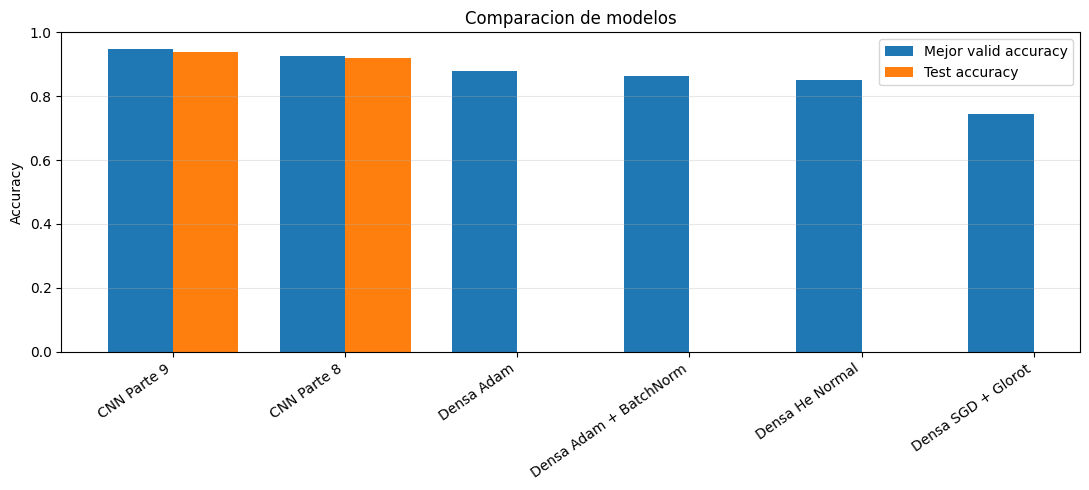

In [28]:
# Parte 9 - Comparacion
required_variables = ["part9_history", "part9_test_accuracy", "part9_test_loss"]
missing_variables = [name for name in required_variables if name not in globals()]
if missing_variables:
    raise RuntimeError(f"Ejecute primero el entrenamiento de Parte 9. Faltan: {missing_variables}")

comparison_rows = []

def add_results_df_row(model_name, results_df_name):
    if results_df_name not in globals():
        return
    results_df = globals()[results_df_name]
    best_row = results_df.sort_values("valid_accuracy", ascending=False).iloc[0]
    comparison_rows.append(
        {
            "model": model_name,
            "best_learning_rate": best_row.get("learning_rate", np.nan),
            "best_valid_accuracy": best_row["valid_accuracy"],
            "test_accuracy": np.nan,
            "best_valid_loss": best_row.get("valid_loss", np.nan),
            "test_loss": np.nan,
            "params": np.nan,
        }
    )

add_results_df_row("Densa SGD + Glorot", "part4_results_df")
add_results_df_row("Densa He Normal", "he_results_df")
add_results_df_row("Densa Adam", "adam_results_df")
add_results_df_row("Densa Adam + BatchNorm", "adam_batch_norm_results_df")

if "cnn_history" in globals():
    comparison_rows.append(
        {
            "model": "CNN Parte 8",
            "best_learning_rate": globals().get("cnn_learning_rate", np.nan),
            "best_valid_accuracy": max(cnn_history.history["val_accuracy"]),
            "test_accuracy": globals().get("cnn_test_accuracy", np.nan),
            "best_valid_loss": min(cnn_history.history["val_loss"]),
            "test_loss": globals().get("cnn_test_loss", np.nan),
            "params": cnn_model.count_params() if "cnn_model" in globals() else np.nan,
        }
    )

comparison_rows.append(
    {
        "model": "CNN Parte 9",
        "best_learning_rate": part9_config["learning_rate"],
        "best_valid_accuracy": max(part9_history.history["val_accuracy"]),
        "test_accuracy": part9_test_accuracy,
        "best_valid_loss": min(part9_history.history["val_loss"]),
        "test_loss": part9_test_loss,
        "params": part9_model.count_params(),
    }
)

part9_comparison_df = pd.DataFrame(comparison_rows)
part9_comparison_df["ranking_score"] = part9_comparison_df["test_accuracy"].fillna(
    part9_comparison_df["best_valid_accuracy"]
)
part9_comparison_df = (
    part9_comparison_df
    .sort_values("ranking_score", ascending=False)
    .drop(columns="ranking_score")
    .reset_index(drop=True)
)

display(part9_comparison_df)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(part9_comparison_df))
bar_width = 0.38

ax.bar(
    x - bar_width / 2,
    part9_comparison_df["best_valid_accuracy"],
    width=bar_width,
    label="Mejor valid accuracy",
)
ax.bar(
    x + bar_width / 2,
    part9_comparison_df["test_accuracy"],
    width=bar_width,
    label="Test accuracy",
)

ax.set_title("Comparacion de modelos")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(part9_comparison_df["model"], rotation=35, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusión final

En la parte 9, el mejor resultado se obtuvo con una red convolucional más profunda que la de la parte 8, usando tres bloques convolucionales, `BatchNormalization`, `Dropout`, inicialización `he_normal`, Adam y callbacks. El modelo alcanzó una `valid_accuracy` máxima de `0.9464` y una `test_accuracy` de `0.9385`, superando a la CNN de la parte 8, que había obtenido `test_accuracy = 0.9204`.

La mejora no vino solamente de hacer el modelo más grande, sino de combinar varias decisiones que vimos durante el notebook: usar una arquitectura convolucional para aprovechar la estructura espacial de las imágenes, estabilizar el entrenamiento con Batch Normalization, reducir sobreajuste con Dropout y ajustar el learning rate durante el entrenamiento con `ReduceLROnPlateau`. El modelo de parte 9 tiene `854,602` parámetros, bastante más que la CNN anterior (`258,186`), por lo que la mejora tiene también un costo mayor en complejidad.

A lo largo del notebook se ve una progresión clara. El modelo denso base con SGD y `glorot_uniform` llegó a una validación de aproximadamente `0.7439`. Cambiar la inicialización a `he_normal` mejoró el entrenamiento de redes profundas con ReLU hasta `0.8517`. Usar Adam fue todavía mejor para las redes densas, alcanzando `0.8788`, aunque con learning rates grandes se volvió inestable. Batch Normalization ayudó especialmente a estabilizar esos casos, aunque no siempre mejoró el mejor resultado absoluto.

La conclusión general es que para Fashion MNIST la arquitectura importa mucho, las redes densas pueden aprender patrones útiles, pero las convolucionales capturan mejor la información local de las imágenes. El mejor clasificador del notebook fue la CNN optimizada de la parte 9, con `test_accuracy = 0.9385`.